In [55]:
from __future__ import print_function
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from metpy.plots import USCOUNTIES
import nexradaws
conn = nexradaws.NexradAwsInterface()
import numpy as np
import numpy.ma as ma
norm = np.linalg.norm
import os
import pandas as pd
import pickle
from PIL import Image
import pyart
import pymap3d as pm
import pyxlma.lmalib.flash.properties
from pyxlma.lmalib.io import read as lma_read
from pyxlma.plot.interactive import InteractiveLMAPlot
import pyxlma.plot.xlma_super_plot_feature
import pyxlma.plot.radar as lmarad
from pypalettes import load_cmap
from scipy import stats
from scipy import spatial
from scipy.spatial import ConvexHull, convex_hull_plot_2d
import gc
import glob
import urllib.request
import warnings
warnings.filterwarnings("ignore")
import xarray as xr
import zipfile
try:
    from metpy.plots import USCOUNTIES
    county_scales = ['20m', '5m', '500k']
    COUNTIES = USCOUNTIES.with_scale(county_scales[0])
except ImportError:
    COUNTIES = None

In [2]:
#Bee's
obsticles = "https://aeronav.faa.gov/Obst_Data/DOF_250511.zip"
urllib.request.urlretrieve(obsticles, "DOF_250511.zip")

zipdata = zipfile.ZipFile('DOF_250511.zip')
zipinfos = zipdata.infolist()

entln_data = lma_read.entln('LEE_ENTLN_Sample.csv')

# iterate through each file
for zipinfo in zipinfos:
    # This will do the renaming
    if '.csv' in zipinfo.filename:
        print("Found ", zipinfo.filename)
    # We can override the filename. Neat!\n",
    zipinfo.filename = 'turbine_locations.csv'
    zipdata.extract(zipinfo)


def haversine(lat1, lon1, lat2, lon2):

      R = 6378.137e3 # this is in meters.  For Earth radius in kilometers use 6372.8 km

      dLat = radians(lat2 - lat1)
      dLon = radians(lon2 - lon1)
      lat1 = radians(lat1)
      lat2 = radians(lat2)

      a = sin(dLat/2)**2 + cos(lat1)*cos(lat2)*sin(dLon/2)**2
      c = 2*asin(sqrt(a))

      return R * c    

#Bee's
data = zipfile.ZipFile('DOF_250511.zip')
infos = data.infolist()

for info in infos:
    if '36-NY' in info.filename:
        print(info.filename)
        info.filename = 'NewYork_Obsticles.Dat'
        data.extract(info)
        
for info in infos:
    if '46-SD' in info.filename:
        print(info.filename)
        info.filename = 'SouthDakota_Obsticles.Dat'
        data.extract(info)
        

36-NY.Dat
46-SD.Dat


In [14]:
#May need to change the file path to match wherever this file is saved
ds = xr.open_dataset('./lmaworkshop/LEE-2023/LYLOUT_221120_070000_28800_map4000.nc')
starttime, endtime = ds.grid_time_edge[0].data, ds.grid_time_edge[-1].data

lma_ctr_lon, lma_ctr_lat = ds.network_center_longitude.data, ds.network_center_latitude.data

OSW_lat, OSW_lon = 43.454722, -76.506667
Lowville_lat, Lowville_lon = 43.786667, -75.492222
KTYX_lat, KTYX_lon, KTYX_alt = 43.7558, -75.68, 562.0
Smokestack_lat, Smokestack_lon = 43.4592, -76.5312

station_lons = [OSW_lon, Lowville_lon, KTYX_lon, Smokestack_lon]
station_lats = [OSW_lat, Lowville_lat, KTYX_lat, Smokestack_lat]
station_labels = ['Oswego', 'Lowville', 'KTYX', 'Smokestack']

# Manually set the encoding because someone didn't use UTF-8 like they should have.
#turbines = pd.read_csv('/Users/BenLa/.spyder-py3/turbine_locations.csv', encoding = "ISO-8859-1")
#nearby_turbines = ((turbines.xlong > lma_ctr_lon - 3.0) & (turbines.xlong < lma_ctr_lon + 3.0) & (turbines.ylat > lma_ctr_lat - 3.0) & (turbines.ylat < lma_ctr_lat + 3.0))
#turbines = turbines[nearby_turbines]

DOF = 'NewYork_Obsticles.Dat'
#DOF = '/Users/BenLa/.spyder-py3/SouthDakota_Obsticles.Dat'

#Bee's\n",
#identify different columns within NewYork_Obsticles.Dat and set them to the corresponding variables
#also skip the first 9000-ish rows as those are all downstate and not apart of our area of interest
specs = [(35, 37), (37, 41), (41, 46), (48, 52), (52, 55), (55, 60), (82, 88), (62, 74)]
StateObs2 = pd.read_fwf(DOF, colspecs = specs, skiprows=4, names=('ylatdeg', 'ylatmin', 'ylatsec', 'xlongdeg', 'xlongmin', 'xlongsec', 'Elevation (ft)', 'Obsticle'))
#NYObs2 = pd.read_fwf('D:/NewYork_Obsticles.Dat', colspecs = specs, skiprows=9209, skipfooter =1,  names=('ylatdeg', 'ylatmin', 'ylatsec', 'xlongdeg', 'xlongmin', 'xlongsec', 'Elevation (ft)', 'Obsticle'))

#Bee's
#convert the deg/min/sec for lat and long to decimal format
StateObs2['ylat']=StateObs2['ylatdeg']+StateObs2['ylatmin']/60+StateObs2['ylatsec']/3600
StateObs2['xlong']=(StateObs2['xlongdeg']+StateObs2['xlongmin']/60+StateObs2['xlongsec']/3600)*-1

#Bee's
#get rid of the deg/min/sec columns and send it to a csv file
StateObs2.drop(columns=['ylatdeg', 'ylatmin', 'ylatsec', 'xlongdeg', 'xlongmin', 'xlongsec']).to_csv(r'/Users/BenLa/.spyder-py3/State_Obsticles.csv')


In [15]:
class SuperLMAPlot(InteractiveLMAPlot):
    def make_super_plot(self):
        super(SuperLMAPlot, self).make_super_plot()
        # Add our own title
        tlim = self.bounds['t']
        tlim_sub = pd.to_datetime(tlim[0]), pd.to_datetime(tlim[1])
        title = tlim_sub[0].strftime('%Y%m%d %H%M%S') + ' to ' + tlim_sub[1].strftime('%Y%m%d %H%M%S') + ' UTC'
        self.lma_plot.ax_th.set_title(title)
        
        # Add the station positions we defined above, and label them. We only need to add them to the plan-view plot.
        # The other axes are self.lma_plot.ax_th, .ax_lon, and .ax_lat.
        new_artists = []
        art = self.lma_plot.ax_plan.scatter(station_lons, station_lats, s = 1, color='k', zorder=-10, mouseover = True)
        new_artists.append(art)
        for slon,slat,slabel in zip(station_lons, station_lats, station_labels):
            txt_art = self.lma_plot.ax_plan.text(slon, slat, slabel)
            new_artists.append(txt_art)
            
        #Bee's
        #Add all the other obstacles and turbines from the NewYork_Obsticles File
        obs_colour = (0.0,1.0,0.2,0.3)
        art = self.lma_plot.ax_plan.scatter(StateObs2.xlong, StateObs2.ylat, color = obs_colour, marker = '1', zorder=-10)
        new_artists.append(art)

In [52]:
#Set the radar time to a desired start
radar_id = 'KTYX'
begin = dt.datetime(2022,11,20,9)
#Spacing is how many minutes on respective sides of the begin time to download the radar files for
spacing = [10, 60*4]

start=begin - dt.timedelta(minutes=spacing[0])
end = begin + dt.timedelta(minutes=spacing[1])

# Create a folder to store the data
downloadloc = f'{start:%Y%m%d%H}_{radar_id}'

# Determine What scans are avaiable for the radar site and times listed
scans = conn.get_avail_scans_in_range(start, end, radar_id)

print("There are {} scans available between {} and {}".format(len(scans), start, end))
#print(scans[0:4])

#download the data
for scan in scans:
    #print(scan)
    path = str(scan)[39:63]
    #print(f'./{downloadloc}{path}')
    #2022112008_KTYX/KTYX20221120_125532_V06
    #print(os.path.exists(f'./{downloadloc}{path}'))
    if os.path.exists(f'./{downloadloc}{path}'):
        print(str(scan) + ' exists')
    else:
        results = conn.download(scan, downloadloc)

files = []
files = sorted(glob.glob(f'{downloadloc}/*V06'))

#Create your own list of radar files
#files = []

#It does take a while to read the radar data, but each selection of data should only need to be run once
#So if you make any changes to the time it'll need to be rerun, but no changes will just pass through
#It took this time period +25 minues so a smaller selection is suggested, but one of this size is recommended to show the capabilities
#print(files)
radar_data, start_times = lmarad.ReadRadar(files)
#print(radar_data)
#Start and end points for the cross section through radar grid 
xsecLatLonAlt = [-76.132206, 44.133103, -75.264611, 43.477363, 10] #start lon, start lat, end lon, end lat, maxz

There are 46 scans available between 2022-11-20 08:50:00 and 2022-11-20 13:00:00
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_085240_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_085830_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_085830_V06_MDM> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_090420_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_091011_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_091617_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_092223_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_092826_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_093432_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_094037_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_094643_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX20221120_095249_V06> exists
<AwsNexradFile object - 2022/11/20/KTYX/KTYX2022112

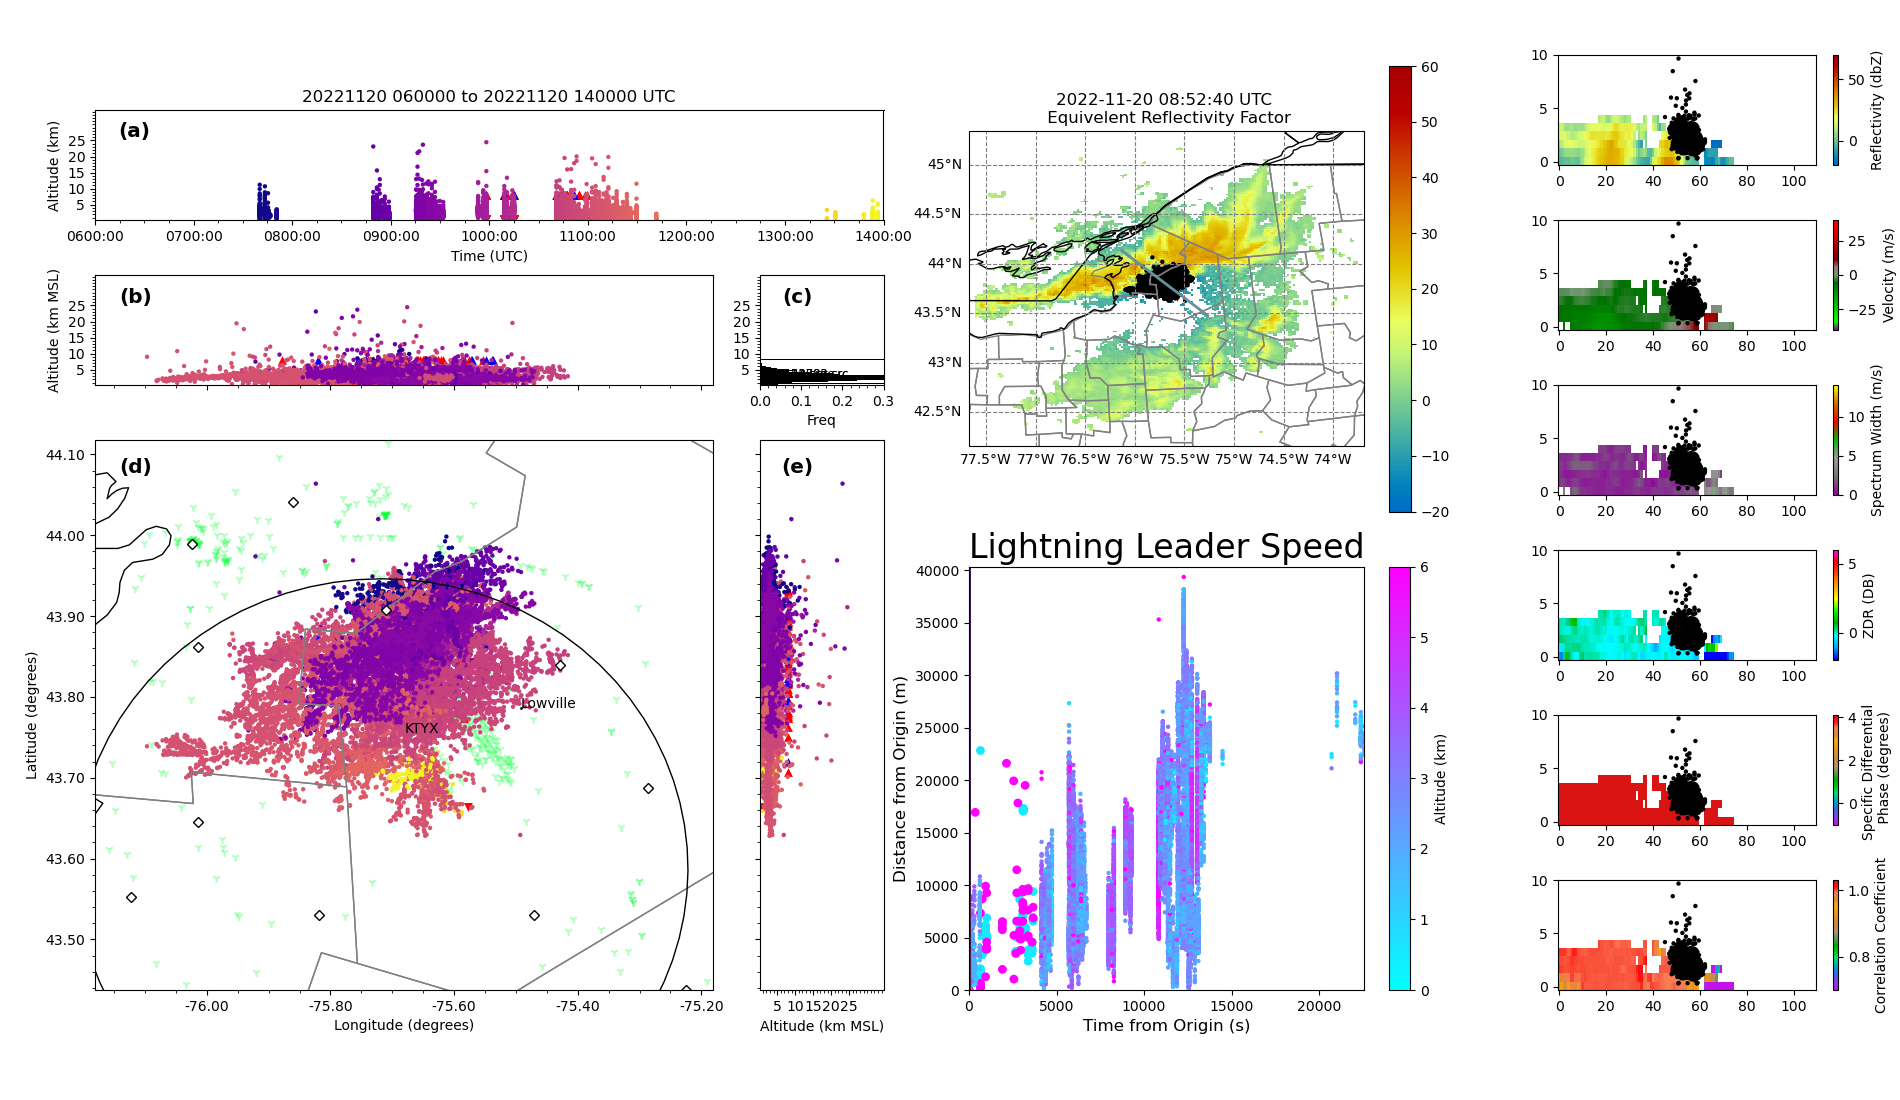

In [53]:
tlim = pd.to_datetime(starttime).to_pydatetime()-pd.Timedelta(hours=1), pd.to_datetime(endtime).to_pydatetime()-pd.Timedelta(hours=1)

#interactive_lma = AnnotatedLMAPlot(ds, clon=lma_ctr_lon, clat=lma_ctr_lat, tlim=tlim) #, network_data = entln_data)

#Instead of creating a regular LMA plot, this will create the 11 panel version with radar, network data, and a leader speed plot
%matplotlib widget
interactive_lma = SuperLMAPlot(ds, clon=lma_ctr_lon, clat=lma_ctr_lat,tlim=tlim, network_data = entln_data, radar_data = radar_data, points = xsecLatLonAlt)

In [56]:
point_1 = np.where(interactive_lma.this_lma_lon == interactive_lma.this_lma_lon.min())[0]
point_2 = np.where(interactive_lma.this_lma_lon == interactive_lma.this_lma_lon.max())[0]

point_3 = np.where(interactive_lma.this_lma_lat == interactive_lma.this_lma_lat.min())[0]
point_4 = np.where(interactive_lma.this_lma_lat == interactive_lma.this_lma_lat.max())[0]

xy = [[a,b] for (a,b) in zip(interactive_lma.this_lma_lon, interactive_lma.this_lma_lat)]

print("Horizontal Flash Area: ")
points = ConvexHull(xy)
area = 1
for k in range(len(points.vertices)-1): 
    #print(k)
    verticies = points.vertices
    np.append(verticies, points.vertices[0])
    area *= haversine(interactive_lma.this_lma_lat[points.vertices[k]], interactive_lma.this_lma_lon[points.vertices[k]], interactive_lma.this_lma_lat[points.vertices[k+1]], interactive_lma.this_lma_lon[points.vertices[k+1]])/1e3
    #print(area)
print(area**0.5)
#print(points.volume)

#print(haversine(interactive_lma.this_lma_lat[point_1], interactive_lma.this_lma_lon[point_1], interactive_lma.this_lma_lat[point_2], interactive_lma.this_lma_lon[point_2]) * (haversine(interactive_lma.this_lma_lat[point_3], interactive_lma.this_lma_lon[point_3], interactive_lma.this_lma_lat[point_4], interactive_lma.this_lma_lon[point_4]))/1000)

print("Vertical Flash Extent: ")
print(interactive_lma.this_lma_alt.max()-interactive_lma.this_lma_alt.min())

print("Flash Duration: ")
print((float(interactive_lma.this_lma_time[interactive_lma.this_lma_time.index[0]].strftime('%S.%f'))-float(interactive_lma.this_lma_time[interactive_lma.this_lma_time.index[-1]].strftime('%S.%f')))*-1)
#print(interactive_lma.this_lma_time[interactive_lma.this_lma_time.index[0]])
#print(interactive_lma.this_lma_time[interactive_lma.this_lma_time.index[-1]])
print("Mean Altitude: ")
print(np.mean((interactive_lma.this_lma_alt)))

Horizontal Flash Area: 


NameError: name 'radians' is not defined